# Logistic Regression for Pharmacy Analytics
## Predicting High-Cost Prescribers from Medicare Part D Data

**Who this is for:** you understand linear regression — fitting a line \( y = b_0 + b_1x_1 + \dots + b_nx_n \) to predict a number — but you've never used logistic regression. This tutorial builds it from that foundation, on real pharmacy data.

**The task:** using CMS Medicare Part D prescribing data, predict whether a prescriber lands in the **top 25% of drug cost per claim** — *without* letting the model see cost. The model must infer expensive prescribing from the prescribing mix alone: brand vs. generic share, specialty, and patient panel characteristics.

**Why a specialty pharmacy cares:** high cost-per-claim prescribers are disproportionately the ones writing specialty medications. Identifying them from prescribing patterns supports clinical program targeting, payer analytics, and network planning.

**Roadmap**

- **Part 1 — Building the model:** get real data, engineer features, see *why linear regression fails* for yes/no outcomes, meet the sigmoid, train, and evaluate — with a graph at every step.
- **Part 2 — Understanding the coefficients:** odds, log(odds), and log(odds ratios) — what the numbers the model learned actually *mean*, and why logistic regression is really just linear regression in disguise.
- **Part 3 — Statistical inference:** transform the y-axis to log(odds) and watch the S-curve become a fitted straight line; Wald's test, p-values, and confidence intervals for the coefficients; and where the t-test you know from linear regression fits into this picture.

## Dataset source

- **Name:** Medicare Part D Prescribers — by Provider (2024 data year)
- **Publisher:** Centers for Medicare & Medicaid Services (CMS); public U.S. Government work, refreshed annually
- **Contents:** one row per prescribing provider (NPI): claims, drug cost, brand/generic mix, opioid counts, beneficiary panel demographics
- **Access:** [data.cms.gov](https://data.cms.gov/provider-summary-by-type-of-service/medicare-part-d-prescribers/medicare-part-d-prescribers-by-provider) — downloaded **live from the internet by the code below**, no API key, no local data file, nothing to install by hand
- **Size:** 1,416,883 providers in the full release. The next cell lets you pull any number of them — or the complete dataset with a one-word change.

## Running in Microsoft Fabric

This notebook is ready for Microsoft Fabric: in your workspace choose **Import > Notebook > From this computer** and select this file. It works in either notebook experience:

- **Fabric notebook (Spark):** the default; runs this pure-Python code on the driver node
- **Python notebook:** pure Python without Spark — cheaper (single node) and ideal for this dataset

`pandas`, `scikit-learn`, `matplotlib`, `requests`, `statsmodels`, and `scipy` are **preinstalled** in the Fabric runtime, and charts render inline exactly as in Jupyter. The data cell downloads from the CMS API on first run (Fabric has outbound internet access by default). If your workspace uses a custom environment missing a library, uncomment and run the cell below.

In [1]:
# Only needed if your Fabric environment lacks these (they are preinstalled by default):
# %pip install scikit-learn pandas matplotlib requests statsmodels scipy

---
# Part 1 — Building the Model

## Step 1.1 — Download the data straight from CMS

No spreadsheet, no download button, no file to keep next to this notebook — the cell below fetches the data over the internet every time it runs. **One setting controls how much you pull:**

| `DATA_ROWS` | What you get | Time | Memory |
|---|---|---|---|
| an integer (e.g. `2_040`, `50_000`) | that many providers, in NPI order, via the JSON API | seconds | small |
| `"full"` | **all 1,416,883 providers** — the complete release, streamed from the bulk CSV in chunks | ~5–15 min (≈2 GB download) | ≈150 MB after trimming to 10 of the 84 columns |

Two access routes, because CMS offers two and each is better at a different job: the **JSON API** is ideal for grabbing the first *N* rows quickly, while the **bulk CSV** is the only sane way to move the whole population. Both are public and key-free.

> **The outputs saved in this notebook were produced with the value shown below.** Change it, choose *Run all*, and every number, table, and graph downstream recomputes on your data — nothing else needs editing.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# ----------------------------- configuration -----------------------------
DATA_ROWS = 2_040        # an integer, or "full" for all 1,416,883 providers
MIN_CLAIMS = 50          # drop very small practices (Step 1.2)
# -------------------------------------------------------------------------

DATASET_ID = "14d8e8a9-7e9b-4370-a044-bf97c46b4b44"
API_URL = f"https://data.cms.gov/data-api/v1/dataset/{DATASET_ID}/data"
BULK_CSV_URL = ("https://data.cms.gov/sites/default/files/2026-05/"
                "e9cd7dfb-9c27-4b3f-8f5d-2454091303ee/MUP_DPR_RY26_P04_V10_DY24_NPI.csv")

COLS = ["Prscrbr_Type", "Tot_Clms", "Tot_Drug_Cst", "Brnd_Tot_Clms", "Gnrc_Tot_Clms",
        "LIS_Tot_Clms", "Opioid_Tot_Clms", "Bene_Avg_Age", "Bene_Avg_Risk_Scre",
        "Bene_Dual_Cnt"]
NUMERIC = [c for c in COLS if c != "Prscrbr_Type"]


def _to_numeric(frame):
    """Every CMS value arrives as text; make the numeric columns numeric."""
    for c in NUMERIC:
        frame[c] = pd.to_numeric(frame[c], errors="coerce")
    return frame


def load_partd(n_rows=DATA_ROWS, page=5_000, chunk=250_000, verbose=True):
    """Download Medicare Part D prescriber data live from data.cms.gov."""
    if n_rows == "full":
        # Bulk CSV: stream in chunks so we never hold the raw 2 GB file in memory.
        header = pd.read_csv(BULK_CSV_URL, nrows=0)
        actual = {c.lower(): c for c in header.columns}      # CMS varies capitalization
        usecols = [actual[c.lower()] for c in COLS]
        parts, seen = [], 0
        for piece in pd.read_csv(BULK_CSV_URL, usecols=usecols, dtype=str,
                                 chunksize=chunk, low_memory=False):
            piece = piece.rename(columns=dict(zip(usecols, COLS)))
            parts.append(_to_numeric(piece))
            seen += len(piece)
            if verbose:
                print(f"  streamed {seen:,} rows", end="\r")
        frame = pd.concat(parts, ignore_index=True)
    else:
        # JSON API: page through the first n_rows records.
        records, offset = [], 0
        while offset < n_rows:
            resp = requests.get(API_URL, timeout=120, params={
                "size": min(page, n_rows - offset), "offset": offset,
                "column": ",".join(COLS)})
            resp.raise_for_status()
            batch = resp.json()
            if not batch:
                break                                   # ran past the end of the data
            records.extend(batch)
            offset += len(batch)
            if verbose:
                print(f"  downloaded {offset:,} rows", end="\r")
        # reindex: the API returns every column when the request is long, so select ours
        frame = _to_numeric(pd.DataFrame(records).reindex(columns=COLS))
    if verbose:
        print(" " * 40, end="\r")
    return frame


raw = load_partd()
print(f"{len(raw):,} providers x {raw.shape[1]} columns, live from data.cms.gov")
raw.head()

2,040 providers x 10 columns, live from data.cms.gov


,Prscrbr_Type,Tot_Clms,Tot_Drug_Cst,Brnd_Tot_Clms,Gnrc_Tot_Clms,LIS_Tot_Clms,Opioid_Tot_Clms,Bene_Avg_Age,Bene_Avg_Risk_Scre,Bene_Dual_Cnt
0,Dentist,43,255.88,0.0,43.0,NaN,0.0,72.333333,1.297948,NaN
1,Physician Assistant,118,464.02,0.0,118.0,20.0,0.0,71.898990,1.334754,11.0
2,Internal Medicine,2055,419734.92,687.0,1368.0,824.0,0.0,71.884393,2.120763,161.0
3,Optometry,90,43050.29,65.0,25.0,13.0,0.0,75.325581,0.926380,NaN
4,Nurse Practitioner,176,853.67,0.0,176.0,122.0,31.0,67.216495,1.505622,53.0


## Step 1.2 — Clean the data

Real claims data has quirks a textbook dataset spares you (text-to-number conversion already happened inside the loader, since every CMS value arrives as a string):

- **Blank cells are suppressed values**: CMS hides counts between 1 and 10 to protect privacy. For count columns we treat blanks as 0 (a simplification that slightly undercounts). For panel averages (age, risk score) blanks are truly missing, so those rows are dropped.
- Keep providers with **at least `MIN_CLAIMS` claims** so rates like brand share aren't small-sample noise.

These rules are size-independent: they behave identically on 2,000 rows or 1.4 million.

In [3]:
df = raw.copy()

count_cols = ["Brnd_Tot_Clms", "Gnrc_Tot_Clms", "LIS_Tot_Clms", "Opioid_Tot_Clms", "Bene_Dual_Cnt"]
df[count_cols] = df[count_cols].fillna(0)
df = df.dropna(subset=["Tot_Clms", "Tot_Drug_Cst", "Bene_Avg_Age", "Bene_Avg_Risk_Scre"])
df = df[df["Tot_Clms"] >= MIN_CLAIMS]
print(f"{len(df):,} providers after cleaning "
      f"({len(raw) - len(df):,} dropped: incomplete panels or under {MIN_CLAIMS} claims)")

1,673 providers after cleaning (367 dropped: incomplete panels or under 50 claims)


## Step 1.3 — Engineer the label and features

**Label:** `high_cost` = 1 if the provider's *cost per claim* is in the top quartile of the sample.

**Features** are rates and shares, so large and small practices are comparable. Crucially, `Tot_Drug_Cst` **defines the label, so it cannot be a feature** — that would be *data leakage*: handing the model the answer produces a perfect, useless classifier.

**One more guard — separation.** If some specialty contains *no* high-cost providers at all (or *only* high-cost providers), that one column predicts the outcome perfectly. Maximum likelihood responds by pushing its coefficient toward −∞: the fit never converges, and the standard errors Part 3 depends on inflate into meaningless intervals. The code below detects such groups and folds them into "Other." Watch whether it prints anything — on this data it does, and Part 3 explains why that matters.

In [4]:
df["cost_per_claim"] = df["Tot_Drug_Cst"] / df["Tot_Clms"]
threshold = df["cost_per_claim"].quantile(0.75)
df["high_cost"] = (df["cost_per_claim"] >= threshold).astype(int)
print(f"High-cost threshold: ${threshold:.2f} per claim")

df["brand_share"] = (df["Brnd_Tot_Clms"] /
                     (df["Brnd_Tot_Clms"] + df["Gnrc_Tot_Clms"]).replace(0, np.nan)).fillna(0)
df["lis_share"] = df["LIS_Tot_Clms"] / df["Tot_Clms"]
df["opioid_share"] = df["Opioid_Tot_Clms"] / df["Tot_Clms"]
df["dual_per_100_clms"] = df["Bene_Dual_Cnt"] / df["Tot_Clms"] * 100
df["log10_claims"] = np.log10(df["Tot_Clms"])

top10 = df["Prscrbr_Type"].value_counts().head(10).index
df["specialty"] = df["Prscrbr_Type"].where(df["Prscrbr_Type"].isin(top10), "Other")

# Guard against SEPARATION -- see the note below.
rates = df.groupby("specialty")["high_cost"].mean()
separated = [s for s in rates.index if s != "Other" and rates[s] in (0.0, 1.0)]
if separated:
    print(f"separation guard: merged into 'Other' -> {', '.join(separated)}")
    df["specialty"] = df["specialty"].where(~df["specialty"].isin(separated), "Other")

numeric_features = ["brand_share", "lis_share", "opioid_share", "dual_per_100_clms",
                    "log10_claims", "Bene_Avg_Age", "Bene_Avg_Risk_Scre"]
X = pd.concat([df[numeric_features],
               pd.get_dummies(df["specialty"], prefix="spec", drop_first=True)], axis=1)
y = df["high_cost"]
print(f"Feature matrix: {X.shape[0]} rows x {X.shape[1]} features")

High-cost threshold: $127.66 per claim
separation guard: merged into 'Other' -> Dentist, Emergency Medicine
Feature matrix: 1673 rows x 15 features


**Graph — what we're working with.** Class balance on the left; on the right, how the single most intuitive feature (brand share) differs between the two classes. Brand drugs cost more, and the separation is already visible — but far from perfect, which is why we need a model that weighs many features at once.

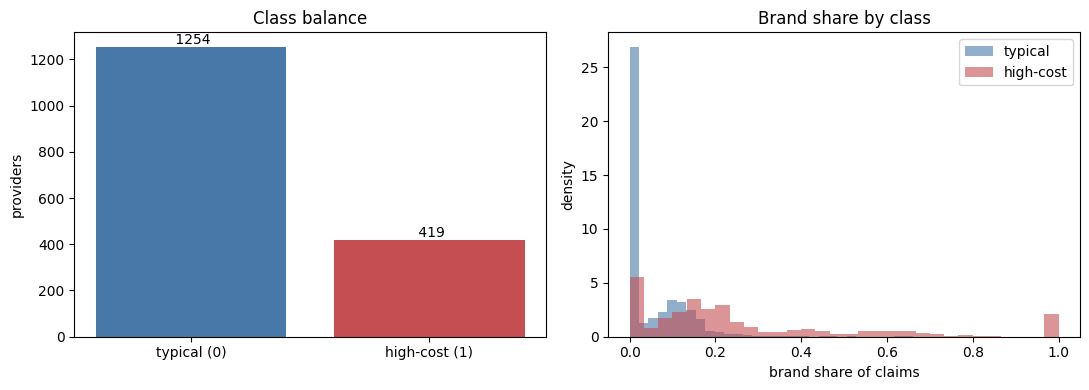

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = y.value_counts().sort_index()
axes[0].bar(["typical (0)", "high-cost (1)"], counts.values, color=["#4878A8", "#C44E52"])
axes[0].set_title("Class balance")
axes[0].set_ylabel("providers")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f" {v}", ha="center", va="bottom")

axes[1].hist(df.loc[y == 0, "brand_share"], bins=30, alpha=0.6, density=True,
             label="typical", color="#4878A8")
axes[1].hist(df.loc[y == 1, "brand_share"], bins=30, alpha=0.6, density=True,
             label="high-cost", color="#C44E52")
axes[1].set_title("Brand share by class")
axes[1].set_xlabel("brand share of claims")
axes[1].set_ylabel("density")
axes[1].legend()
plt.tight_layout()
plt.show()

## Step 1.4 — Why not just use linear regression?

You know linear regression: fit a line and read the prediction off it. Let's try that with one feature (`brand_share`) and our 0/1 outcome, and see the problem with our own eyes.

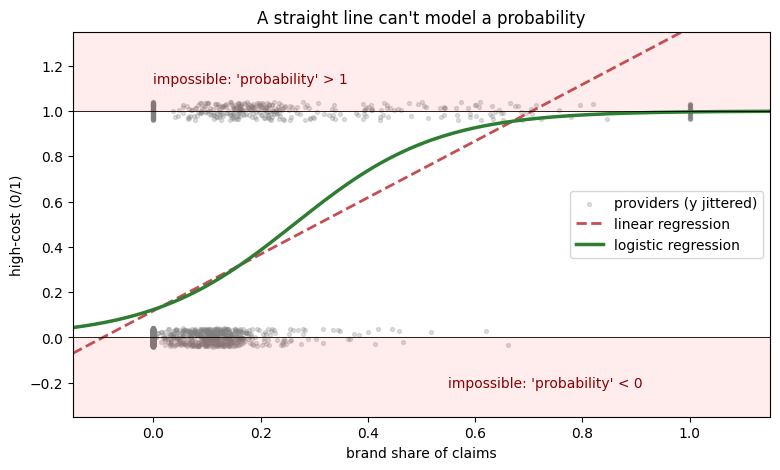

In [6]:
from sklearn.linear_model import LinearRegression, LogisticRegression

xb = df[["brand_share"]].values
lin = LinearRegression().fit(xb, y)
log1 = LogisticRegression().fit(xb, y)

grid = np.linspace(-0.15, 1.15, 300).reshape(-1, 1)
rng = np.random.default_rng(0)
jitter = y + rng.uniform(-0.04, 0.04, len(y))

plt.figure(figsize=(9, 5))
plt.scatter(xb, jitter, s=8, alpha=0.25, color="gray", label="providers (y jittered)")
plt.plot(grid, lin.predict(grid), "--", color="#C44E52", lw=2, label="linear regression")
plt.plot(grid, log1.predict_proba(grid)[:, 1], color="#2E7D32", lw=2.5, label="logistic regression")
plt.axhline(0, color="black", lw=0.6); plt.axhline(1, color="black", lw=0.6)
plt.fill_between([-0.15, 1.15], 1, 1.35, color="red", alpha=0.07)
plt.fill_between([-0.15, 1.15], -0.35, 0, color="red", alpha=0.07)
plt.text(0.0, 1.12, "impossible: 'probability' > 1", color="darkred")
plt.text(0.55, -0.22, "impossible: 'probability' < 0", color="darkred")
plt.ylim(-0.35, 1.35); plt.xlim(-0.15, 1.15)
plt.xlabel("brand share of claims"); plt.ylabel("high-cost (0/1)")
plt.title("A straight line can't model a probability")
plt.legend(loc="center right")
plt.show()

**What the graph shows:** the dashed line happily predicts values above 1 and below 0 — but a probability can't leave [0, 1]. And the outcome isn't a number to begin with; it's a category.

**The fix is one function.** Keep the linear machinery you already know:

$$z = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n$$

but instead of using \(z\) as the prediction, squash it through the **sigmoid** so the output is always a valid probability:

$$p = \frac{1}{1 + e^{-z}}$$

That's the green curve above, and that's all logistic regression is: **a linear model whose output is passed through the sigmoid.**

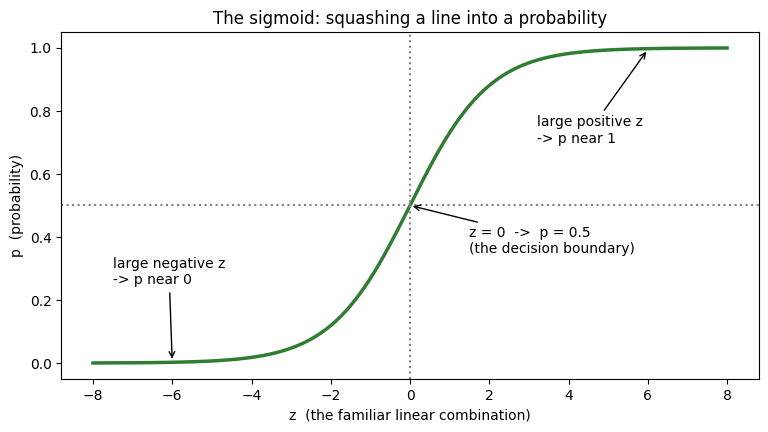

In [7]:
z = np.linspace(-8, 8, 400)
p = 1 / (1 + np.exp(-z))

plt.figure(figsize=(9, 4.5))
plt.plot(z, p, lw=2.5, color="#2E7D32")
plt.axhline(0.5, color="gray", ls=":"); plt.axvline(0, color="gray", ls=":")
plt.annotate("z = 0  ->  p = 0.5\n(the decision boundary)", xy=(0, 0.5), xytext=(1.5, 0.35),
             arrowprops=dict(arrowstyle="->"))
plt.annotate("large negative z\n-> p near 0", xy=(-6, 0.005), xytext=(-7.5, 0.25),
             arrowprops=dict(arrowstyle="->"))
plt.annotate("large positive z\n-> p near 1", xy=(6, 0.995), xytext=(3.2, 0.7),
             arrowprops=dict(arrowstyle="->"))
plt.xlabel("z  (the familiar linear combination)"); plt.ylabel("p  (probability)")
plt.title("The sigmoid: squashing a line into a probability")
plt.show()

## Step 1.5 — Split, scale, train

Standard supervised-learning discipline:

- **Hold out 20%** of providers the model never sees, for an honest performance estimate (`stratify=y` keeps the 75/25 class mix in both halves)
- **Standardize features** to mean 0, std 1 — fit the scaler on training data only, to avoid leaking test-set information
- **Train** on all 17 features at once (instead of the single feature we plotted above)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train_s, y_train)
print(f"Trained on {len(X_train)} providers; testing on {len(X_test)}")

Trained on 1338 providers; testing on 335


## Step 1.6 — Evaluate

With a 75/25 class split, a lazy model that always answers "typical" scores 75% accuracy. So we look past accuracy, at three graphs:

1. **Confusion matrix** — where the errors actually land
2. **Predicted probabilities by true class** — does the model separate the classes?
3. **ROC curve** — ranking quality across every possible threshold (AUC: 1.0 = perfect, 0.5 = coin flip)

In [9]:
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)

y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]

print(f"Baseline (always 'typical'): {(y_test == 0).mean():.3f}")
print(f"Accuracy:                    {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC AUC:                     {roc_auc_score(y_test, y_prob):.3f}\n")
print(classification_report(y_test, y_pred, target_names=["typical", "high-cost"]))

Baseline (always 'typical'): 0.749
Accuracy:                    0.848
ROC AUC:                     0.879

              precision    recall  f1-score   support

     typical       0.85      0.96      0.90       251
   high-cost       0.81      0.51      0.63        84

    accuracy                           0.85       335
   macro avg       0.83      0.74      0.77       335
weighted avg       0.84      0.85      0.83       335



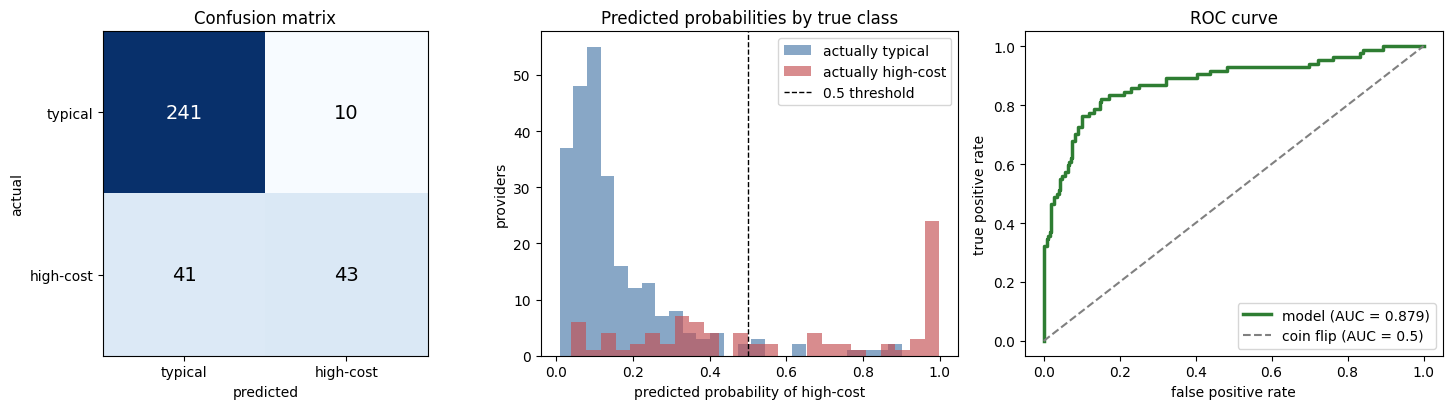

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    axes[0].text(j, i, str(v), ha="center", va="center", fontsize=14,
                 color="white" if v > cm.max()/2 else "black")
axes[0].set_xticks([0, 1], ["typical", "high-cost"])
axes[0].set_yticks([0, 1], ["typical", "high-cost"])
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("actual")
axes[0].set_title("Confusion matrix")

axes[1].hist(y_prob[y_test == 0], bins=25, alpha=0.65, label="actually typical", color="#4878A8")
axes[1].hist(y_prob[y_test == 1], bins=25, alpha=0.65, label="actually high-cost", color="#C44E52")
axes[1].axvline(0.5, color="black", ls="--", lw=1, label="0.5 threshold")
axes[1].set_xlabel("predicted probability of high-cost"); axes[1].set_ylabel("providers")
axes[1].set_title("Predicted probabilities by true class")
axes[1].legend()

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[2].plot(fpr, tpr, lw=2.5, color="#2E7D32",
             label=f"model (AUC = {roc_auc_score(y_test, y_prob):.3f})")
axes[2].plot([0, 1], [0, 1], "--", color="gray", label="coin flip (AUC = 0.5)")
axes[2].set_xlabel("false positive rate"); axes[2].set_ylabel("true positive rate")
axes[2].set_title("ROC curve")
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

**Reading the three panels:**

- **Confusion matrix:** most errors are high-cost prescribers labeled "typical" (bottom-left). The 0.5 threshold is conservative here; a pharmacy screening for outreach candidates might lower it to catch more, accepting more false alarms.
- **Probability histogram:** the blue (typical) mass piles up near 0 and the red (high-cost) mass shifts right — real separation, with an honest overlap zone in the middle.
- **ROC curve:** well above the diagonal at every threshold. This is solid signal for a model that was never shown a single dollar figure.

---
# Part 2 — Understanding the Coefficients: odds, log(odds), and log(odds ratios)

Part 1 gave us a model that works. Part 2 answers the question a reviewer, regulator, or clinical director will actually ask: **what did it learn?**

## Step 2.1 — Odds, and log(odds)

Probability isn't the only way to express chance. **Odds** are the ratio of the chance it happens to the chance it doesn't:

$$\text{odds} = \frac{p}{1-p}$$

- p = 0.5 → odds = 1 (a coin flip, "even odds")
- p = 0.75 → odds = 3 ("3 to 1")
- p = 0.25 → odds = 1/3

Odds are awkwardly asymmetric: "against" outcomes are squeezed into (0, 1) while "for" outcomes stretch to infinity. Taking the **log** fixes the asymmetry — log(odds) of 3-to-1 for and 3-to-1 against become +1.1 and −1.1, mirror images.

**Here's the payoff.** Rearranging the sigmoid from Part 1:

$$\log\!\left(\frac{p}{1-p}\right) = z = b_0 + b_1x_1 + \dots + b_nx_n$$

**Logistic regression IS linear regression — on the log(odds) scale.** Everything you know transfers: each coefficient \(b_i\) is the change in log(odds) per one-unit increase in \(x_i\), holding the others fixed.

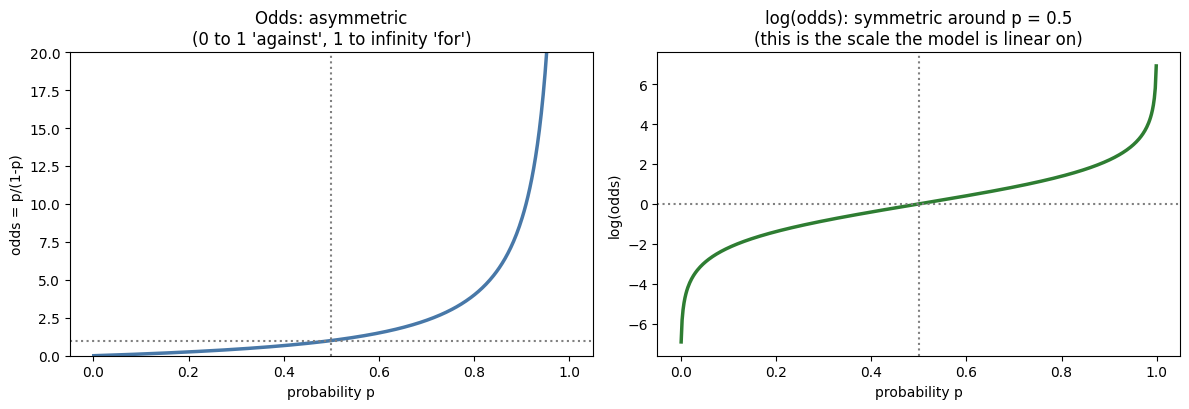

In the training data:  p(high-cost) = 0.250
odds     = 0.334   ('1 to 3.0 against')
log-odds = -1.097  (negative because p < 0.5)


In [11]:
p_grid = np.linspace(0.001, 0.999, 500)
odds = p_grid / (1 - p_grid)
log_odds = np.log(odds)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(p_grid, odds, lw=2.5, color="#4878A8")
axes[0].axvline(0.5, color="gray", ls=":"); axes[0].axhline(1, color="gray", ls=":")
axes[0].set_ylim(0, 20)
axes[0].set_xlabel("probability p"); axes[0].set_ylabel("odds = p/(1-p)")
axes[0].set_title("Odds: asymmetric\n(0 to 1 'against', 1 to infinity 'for')")

axes[1].plot(p_grid, log_odds, lw=2.5, color="#2E7D32")
axes[1].axvline(0.5, color="gray", ls=":"); axes[1].axhline(0, color="gray", ls=":")
axes[1].set_xlabel("probability p"); axes[1].set_ylabel("log(odds)")
axes[1].set_title("log(odds): symmetric around p = 0.5\n(this is the scale the model is linear on)")
plt.tight_layout()
plt.show()

# concrete numbers from our own data
p_high = y_train.mean()
print(f"In the training data:  p(high-cost) = {p_high:.3f}")
print(f"odds     = {p_high/(1-p_high):.3f}   ('1 to {(1-p_high)/p_high:.1f} against')")
print(f"log-odds = {np.log(p_high/(1-p_high)):+.3f}  (negative because p < 0.5)")

## Step 2.2 — Coefficients are changes in log(odds)

Because we standardized the features, each coefficient answers: *"if this feature increases by one standard deviation, how much does the log(odds) of being high-cost change, all else held fixed?"*

The intercept is the log(odds) for a hypothetical provider at the average of every feature (and in the reference specialty).

Intercept (log-odds at all-average): -1.39


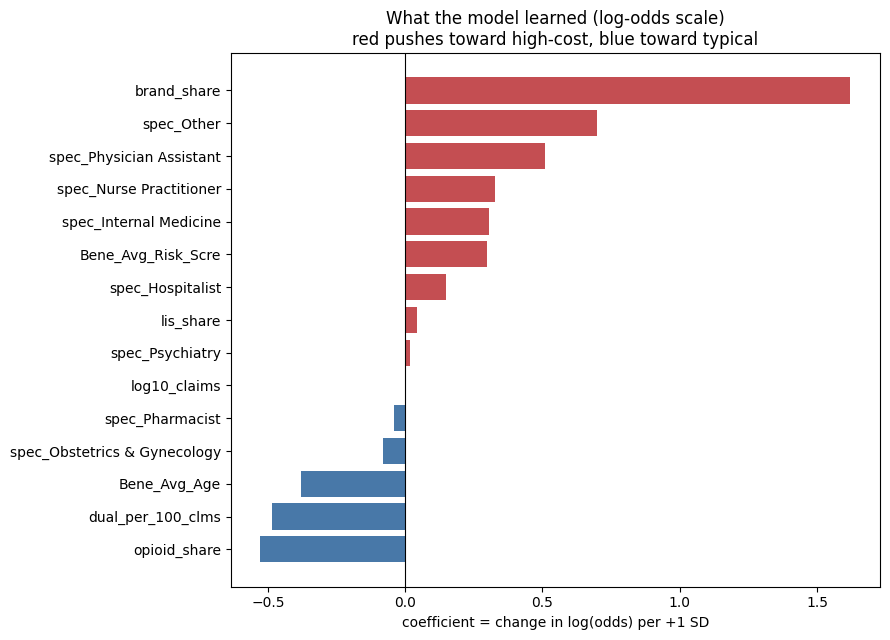

In [12]:
weights = pd.Series(model.coef_[0], index=X.columns).sort_values()
print(f"Intercept (log-odds at all-average): {model.intercept_[0]:+.2f}")

plt.figure(figsize=(9, 6.5))
colors = ["#C44E52" if w > 0 else "#4878A8" for w in weights]
plt.barh(weights.index, weights.values, color=colors)
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("coefficient = change in log(odds) per +1 SD")
plt.title("What the model learned (log-odds scale)\nred pushes toward high-cost, blue toward typical")
plt.tight_layout()
plt.show()

## Step 2.3 — From log(odds) to odds ratios

Log(odds) are the model's natural scale but nobody *thinks* in them. Exponentiating a coefficient gives an **odds ratio (OR)**:

$$OR_i = e^{b_i} = \frac{\text{odds when } x_i \text{ is one unit higher}}{\text{odds at baseline}}$$

- **OR = 1** — no effect (this is why the reference line on the chart sits at 1, not 0)
- **OR = 2** — one unit higher doubles the odds
- **OR = 0.5** — one unit higher halves the odds

And the **log(odds ratio)** is just the coefficient itself: \(\log(OR_i) = b_i\). The two charts below are the same information on two scales — coefficients (log(OR), symmetric around 0) and odds ratios (multiplicative, symmetric around 1 on a log axis). Doubling and halving the odds are the same *distance* on both.

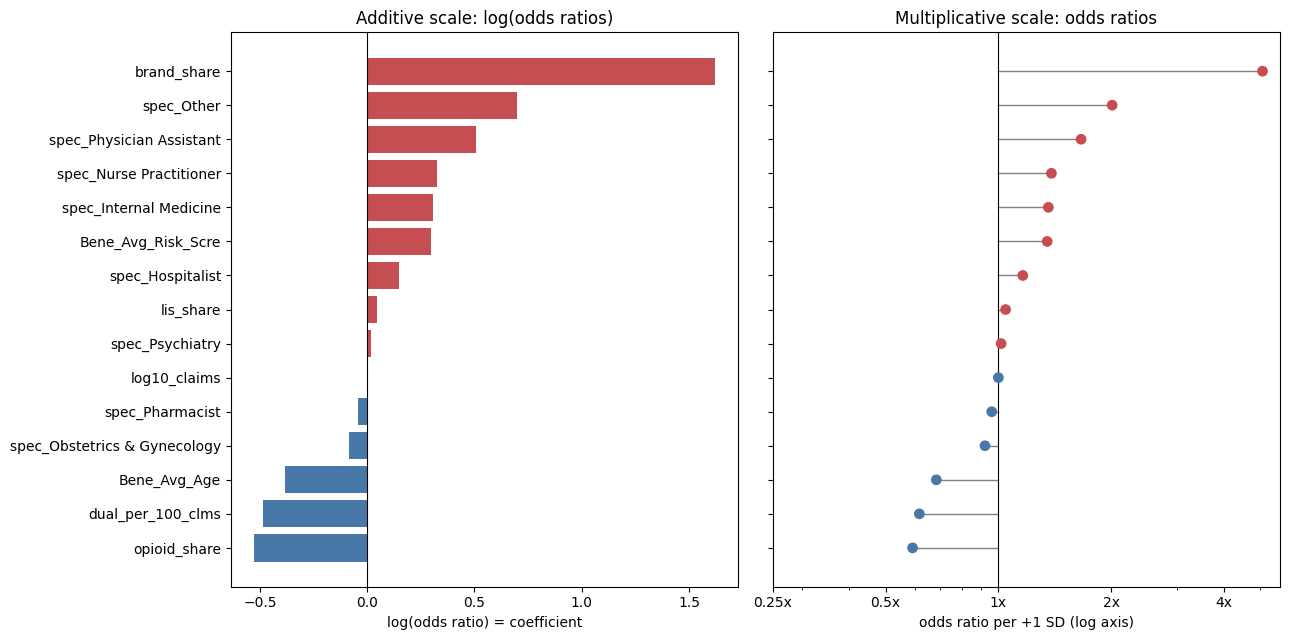

Largest positive effect: brand_share
  coefficient (log-OR): +1.62
  odds ratio:            5.06x per +1 SD (+1 SD of brand_share = 0.181 in share terms)


In [13]:
or_series = np.exp(weights)

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5), sharey=True)

axes[0].barh(weights.index, weights.values, color=colors)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("log(odds ratio) = coefficient")
axes[0].set_title("Additive scale: log(odds ratios)")

axes[1].scatter(or_series.values, or_series.index, color=colors, s=45, zorder=3)
for name, v in or_series.items():
    axes[1].plot([1, v], [name, name], color="gray", lw=1, zorder=2)
axes[1].axvline(1, color="black", lw=0.8)
axes[1].set_xscale("log")
axes[1].set_xticks([0.25, 0.5, 1, 2, 4], ["0.25x", "0.5x", "1x", "2x", "4x"])
axes[1].set_xlabel("odds ratio per +1 SD (log axis)")
axes[1].set_title("Multiplicative scale: odds ratios")

plt.tight_layout()
plt.show()

top = weights.idxmax()
print(f"Largest positive effect: {top}")
print(f"  coefficient (log-OR): {weights[top]:+.2f}")
print(f"  odds ratio:            {np.exp(weights[top]):.2f}x per +1 SD "
      f"(+1 SD of brand_share = {X['brand_share'].std():.3f} in share terms)")

## Step 2.4 — A worked example: brand share

Let's trace one feature all the way through, in plain numbers, for a provider who is average on everything else.

brand_share at +0 SD:  log-odds = -1.39   odds = 0.25   p(high-cost) = 19.9%
brand_share at +1 SD:  log-odds = +0.23   odds = 1.26   p(high-cost) = 55.8%
brand_share at +2 SD:  log-odds = +1.85   odds = 6.38   p(high-cost) = 86.5%

Each +1 SD of brand share multiplies the odds by e^1.62 = 5.06 — the same multiplier every step,
which is exactly what 'linear in log(odds)' means.


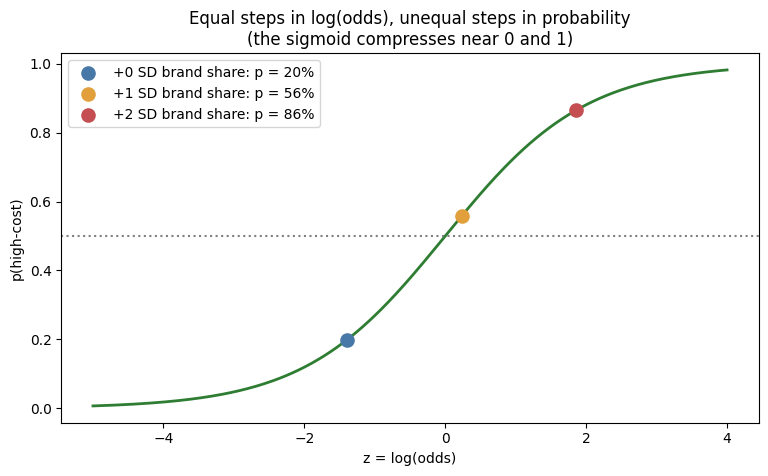

In [14]:
b0 = model.intercept_[0]
b_brand = model.coef_[0][list(X.columns).index("brand_share")]

for sds in [0, 1, 2]:
    z = b0 + b_brand * sds
    odds_v = np.exp(z)
    p_v = 1 / (1 + np.exp(-z))
    print(f"brand_share at +{sds} SD:  log-odds = {z:+.2f}   "
          f"odds = {odds_v:.2f}   p(high-cost) = {p_v:.1%}")

print(f"\nEach +1 SD of brand share multiplies the odds by e^{b_brand:.2f} = {np.exp(b_brand):.2f} "
      f"— the same multiplier every step,\nwhich is exactly what 'linear in log(odds)' means.")

# visualize on the sigmoid
z_grid = np.linspace(-5, 4, 300)
plt.figure(figsize=(9, 4.8))
plt.plot(z_grid, 1/(1+np.exp(-z_grid)), lw=2, color="#2E7D32")
for sds, marker_color in zip([0, 1, 2], ["#4878A8", "#E1A03C", "#C44E52"]):
    zv = b0 + b_brand * sds
    pv = 1/(1+np.exp(-zv))
    plt.scatter([zv], [pv], s=90, color=marker_color, zorder=3,
                label=f"+{sds} SD brand share: p = {pv:.0%}")
plt.axhline(0.5, color="gray", ls=":")
plt.xlabel("z = log(odds)"); plt.ylabel("p(high-cost)")
plt.title("Equal steps in log(odds), unequal steps in probability\n(the sigmoid compresses near 0 and 1)")
plt.legend()
plt.show()

**The subtle point the last graph makes:** each +1 SD of brand share adds the *same amount* to the log(odds) — but the *probability* change depends on where you start. Near p = 0.5 the sigmoid is steep and a step matters a lot; near the extremes it barely moves. This is why honest reporting uses odds ratios ("2.5x the odds"), not "adds 20 percentage points."


---
# Part 3 — Statistical Inference: Wald's Test, p-values, and the Log-Odds Line

Part 2 told us what the coefficients *mean*. Part 3 asks the question every reviewer asks next: **should we believe them?** Could a coefficient this size appear by chance in a sample of ~1,300 training providers?

## Step 3.1 — Seeing the "linear" in logistic regression: transform the y-axis

Part 2 *claimed* the model is a straight line on the log(odds) scale. Let's verify it with the data itself. We bin providers by brand share, compute the **observed** fraction of high-cost providers in each bin, and plot that fraction twice — once as a probability, once converted to log(odds):

$$\text{observed log(odds)} = \log\!\left(\frac{\hat p_{bin}}{1-\hat p_{bin}}\right)$$

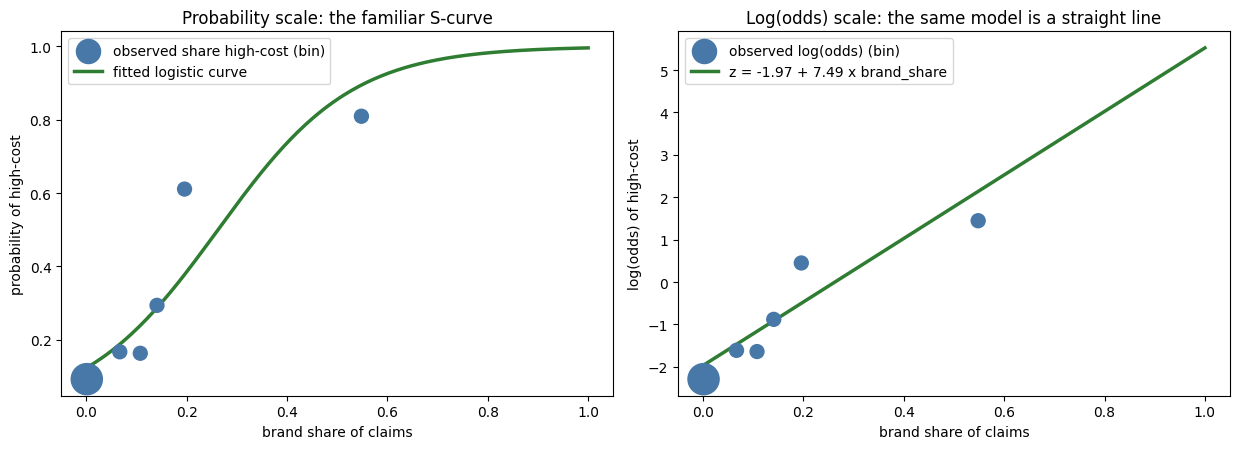

Read the right panel exactly like a linear regression fit:
  intercept -1.97 = log(odds) at brand share 0
  slope     +7.49 = change in log(odds) per +1.0 of brand share


In [15]:
# a one-feature model so the picture is honest (this is the model being drawn)
xb = df[["brand_share"]].values
m1 = LogisticRegression().fit(xb, y)
b0_1, b1_1 = m1.intercept_[0], m1.coef_[0][0]

# bin the data and compute observed proportions per bin
bins = pd.qcut(df["brand_share"], 10, duplicates="drop")
g = (df.assign(hc=y).groupby(bins, observed=True)
       .agg(x=("brand_share", "mean"), p=("hc", "mean"), n=("hc", "size")))
g = g[(g["p"] > 0) & (g["p"] < 1)]                    # log-odds undefined at 0 or 1
g["log_odds"] = np.log(g["p"] / (1 - g["p"]))

grid = np.linspace(df["brand_share"].min(), df["brand_share"].max(), 200)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
axes[0].scatter(g["x"], g["p"], s=g["n"] * 0.6, color="#4878A8", zorder=3,
                label="observed share high-cost (bin)")
axes[0].plot(grid, 1 / (1 + np.exp(-(b0_1 + b1_1 * grid))), color="#2E7D32", lw=2.5,
             label="fitted logistic curve")
axes[0].set_xlabel("brand share of claims"); axes[0].set_ylabel("probability of high-cost")
axes[0].set_title("Probability scale: the familiar S-curve")
axes[0].legend()

axes[1].scatter(g["x"], g["log_odds"], s=g["n"] * 0.6, color="#4878A8", zorder=3,
                label="observed log(odds) (bin)")
axes[1].plot(grid, b0_1 + b1_1 * grid, color="#2E7D32", lw=2.5,
             label=f"z = {b0_1:.2f} + {b1_1:.2f} x brand_share")
axes[1].set_xlabel("brand share of claims"); axes[1].set_ylabel("log(odds) of high-cost")
axes[1].set_title("Log(odds) scale: the same model is a straight line")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Read the right panel exactly like a linear regression fit:")
print(f"  intercept {b0_1:+.2f} = log(odds) at brand share 0")
print(f"  slope     {b1_1:+.2f} = change in log(odds) per +1.0 of brand share")

**What the graph shows:** the *same data and same model*, on two y-axes. On the left, the familiar S-curve. On the right — after transforming the y-axis from probability to log(odds) — the binned data points fall along a **straight line**, and the model *is* that line. Slope and intercept read exactly like linear regression. (Bubble size is the number of providers per bin; sparse extreme bins scatter more, which is normal.)

## Step 3.2 — Refit with statsmodels: the full regression table

scikit-learn is built for prediction and reports no standard errors or p-values. For inference, the standard tool is **statsmodels**, which fits the same model by maximum likelihood and reports the full table.

*One honest wrinkle:* scikit-learn applies mild L2 regularization by default, statsmodels fits unpenalized — so coefficients differ slightly. For inference, the unpenalized fit is the convention.

In [16]:
import statsmodels.api as sm

Xs_train = pd.DataFrame(X_train_s, columns=X.columns, index=X_train.index).astype(float)
sm_model = sm.Logit(y_train.astype(float), sm.add_constant(Xs_train)).fit(disp=0)
print(sm_model.summary())

                           Logit Regression Results                           
Dep. Variable:              high_cost   No. Observations:                 1338
Model:                          Logit   Df Residuals:                     1322
Method:                           MLE   Df Model:                           15
Date:                Thu, 06 Aug 2026   Pseudo R-squ.:                  0.3131
Time:                        14:11:57   Log-Likelihood:                -517.17
converged:                       True   LL-Null:                       -752.95
Covariance Type:            nonrobust   LLR p-value:                 5.772e-91
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -1.3985      0.095    -14.713      0.000      -1.585      -1.212
brand_share                      1.6533      0.141     11.752      0.000     

**Check `converged: True` in the header first.** If it says `False`, every standard error below is suspect — that is the separation problem from Step 1.3, and it is why we folded perfectly-predicting specialties into "Other." Without that guard this exact model reports an intercept standard error of roughly 394,000 and a 95% confidence interval of ±771,000: numerically "valid," completely meaningless. It is a good habit to glance at that one word before reading any p-value.

**How to read the table** (the header also reports **McFadden's pseudo-R²** — loosely, the improvement in log-likelihood over an intercept-only model; 0.2–0.4 is considered strong for logistic regression):

| Column | Meaning |
|---|---|
| `coef` | the coefficient — change in log(odds) per +1 SD (Part 2) |
| `std err` | its standard error: how much it would wobble across repeated samples |
| `z` | **the Wald statistic** = coef / std err |
| `P>|z|` | the Wald p-value |
| `[0.025, 0.975]` | 95% confidence interval for the coefficient |

## Step 3.3 — Wald's test

For each coefficient, Wald's test asks: *if the true coefficient were 0 (odds ratio = 1, no effect), how surprising is the estimate we got?*

$$z = \frac{\hat b}{SE(\hat b)} \quad\text{compared against the standard normal distribution}$$

- **|z| > 1.96** → p < 0.05 → "statistically significant at the 5% level"
- **Wald's known weakness:** under separation (or with very large coefficients) the test misbehaves badly — the standard error grows faster than the coefficient, so a genuinely strong effect can look *insignificant*. The likelihood-ratio test is the robust alternative, and Firth's penalized likelihood is the standard remedy when you must keep separated categories rather than merging them
- **95% CI** = \(\hat b \pm 1.96 \cdot SE\); exponentiate the endpoints for the odds-ratio CI
- Equivalent statements: *the log-odds CI excludes 0* ⟺ *the odds-ratio CI excludes 1* ⟺ *p < 0.05*

Let's compute it by hand for brand share and confirm it matches the table:

In [17]:
from scipy import stats

b_hat = sm_model.params["brand_share"]
se = sm_model.bse["brand_share"]
z_wald = b_hat / se
p_wald = 2 * (1 - stats.norm.cdf(abs(z_wald)))
ci_lo, ci_hi = b_hat - 1.96 * se, b_hat + 1.96 * se

print("Wald's test for brand_share, by hand:")
print(f"  coefficient:      {b_hat:+.4f}")
print(f"  standard error:    {se:.4f}")
print(f"  z = coef/SE:      {z_wald:+.2f}   (|z| > 1.96 -> significant)")
print(f"  p-value:           {p_wald:.2e}")
print(f"  95% CI (log-odds): [{ci_lo:+.3f}, {ci_hi:+.3f}]")
print(f"  95% CI (odds ratio): [{np.exp(ci_lo):.2f}x, {np.exp(ci_hi):.2f}x]  <- excludes 1")

Wald's test for brand_share, by hand:
  coefficient:      +1.6533
  standard error:    0.1407
  z = coef/SE:      +11.75   (|z| > 1.96 -> significant)
  p-value:           0.00e+00
  95% CI (log-odds): [+1.378, +1.929]
  95% CI (odds ratio): [3.97x, 6.88x]  <- excludes 1


**Graph — every coefficient with its Wald 95% confidence interval.** Solid markers are significant (CI excludes 0 / odds-ratio CI excludes 1); hollow markers are not — the data can't rule out 'no effect' for those.

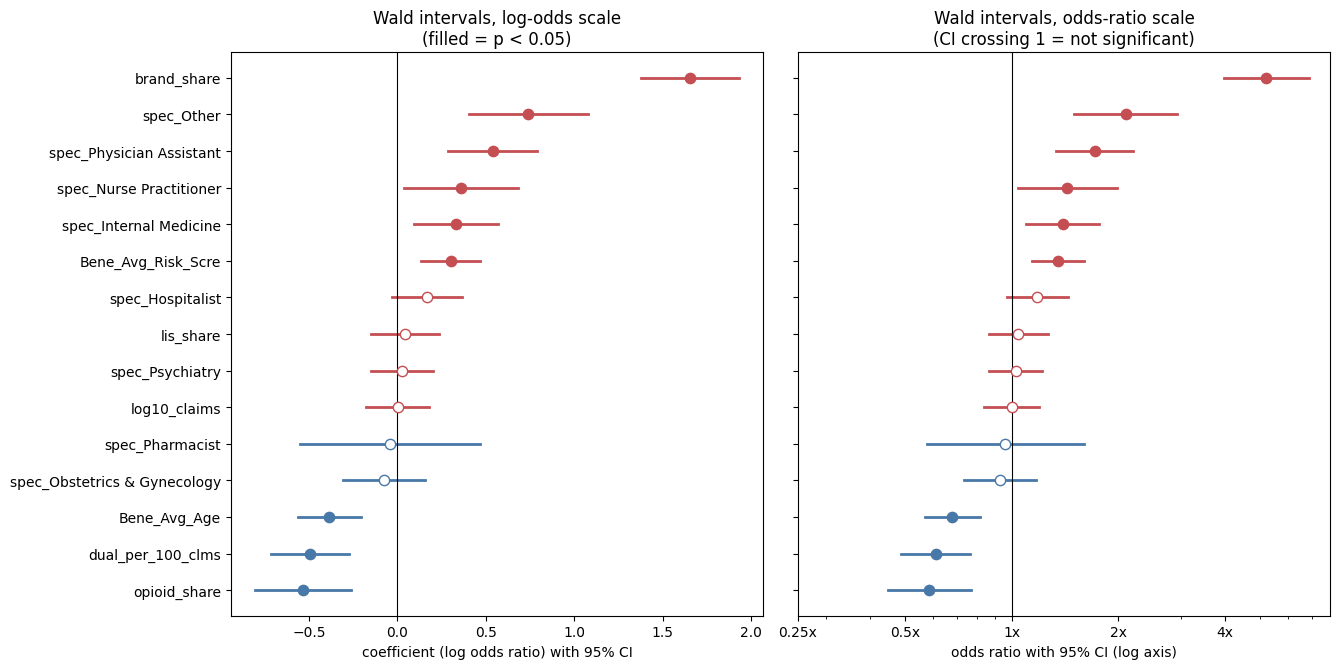

9 of 15 features are significant at p < 0.05


In [18]:
params = sm_model.params.drop("const")
conf = sm_model.conf_int().drop("const")
pvals = sm_model.pvalues.drop("const")
order = params.sort_values().index
sig = pvals < 0.05

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.8), sharey=True)
for name in order:
    color = "#C44E52" if params[name] > 0 else "#4878A8"
    filled = color if sig[name] else "white"
    axes[0].plot(conf.loc[name], [name, name], color=color, lw=2)
    axes[0].scatter(params[name], name, s=55, color=filled, edgecolor=color, zorder=3)
    axes[1].plot(np.exp(conf.loc[name]), [name, name], color=color, lw=2)
    axes[1].scatter(np.exp(params[name]), name, s=55, color=filled, edgecolor=color, zorder=3)

axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("coefficient (log odds ratio) with 95% CI")
axes[0].set_title("Wald intervals, log-odds scale\n(filled = p < 0.05)")
axes[1].axvline(1, color="black", lw=0.8)
axes[1].set_xscale("log")
axes[1].set_xticks([0.25, 0.5, 1, 2, 4], ["0.25x", "0.5x", "1x", "2x", "4x"])
axes[1].set_xlabel("odds ratio with 95% CI (log axis)")
axes[1].set_title("Wald intervals, odds-ratio scale\n(CI crossing 1 = not significant)")
plt.tight_layout()
plt.show()

print(f"{sig.sum()} of {len(sig)} features are significant at p < 0.05")

## Step 3.4 — Where does the t-test fit in?

If you learned linear regression, you tested coefficients with a **t-test**: \(t = \hat b / SE\), compared against a t-distribution. Wald's test has the identical structure — an estimate divided by its uncertainty — so why z instead of t?

- **Linear regression** must *estimate* the residual variance σ² from the data; that extra uncertainty is what produces the heavier-tailed t-distribution.
- **Logistic regression** has no separate residual variance (the Bernoulli variance p(1−p) is determined by p itself), so the statistic is compared against the standard **normal** — a z-test. Same idea, different reference distribution; with 1,300+ observations the two are nearly indistinguishable anyway.

The classic **two-sample t-test** still earns its keep in exploratory analysis, *before* any model — for example: do high-cost and typical prescribers have different mean brand share?

In [19]:
high = df.loc[y == 1, "brand_share"]
typ = df.loc[y == 0, "brand_share"]
t_stat, p_t = stats.ttest_ind(high, typ, equal_var=False)   # Welch's t-test

print("Two-sample (Welch) t-test: mean brand share, high-cost vs typical")
print(f"  mean (high-cost): {high.mean():.3f}   mean (typical): {typ.mean():.3f}")
print(f"  t = {t_stat:.2f},  p = {p_t:.2e}")
print()
print("Compare the two tools:")
print("  t-test  (EDA):   'the two groups differ in average brand share'")
print("  Wald    (model): 'brand share predicts high-cost EVEN AFTER holding")
print("                    specialty, panel age, risk score, etc. fixed'")
print("The Wald test is the multivariable version of the question.")

Two-sample (Welch) t-test: mean brand share, high-cost vs typical
  mean (high-cost): 0.270   mean (typical): 0.052
  t = 15.94,  p = 1.71e-45

Compare the two tools:
  t-test  (EDA):   'the two groups differ in average brand share'
  Wald    (model): 'brand share predicts high-cost EVEN AFTER holding
                    specialty, panel age, risk score, etc. fixed'
The Wald test is the multivariable version of the question.


---
# Wrap-up

**Concepts covered**

- *Part 1:* why a straight line can't model a probability; the sigmoid; leakage-safe feature engineering on real CMS claims data; evaluation with confusion matrix, probability separation, and ROC/AUC against a class-imbalance baseline.
- *Part 2:* odds vs. probability; log(odds) as the scale where logistic regression is linear; coefficients as log(odds ratios); exponentiation to odds ratios; why equal log-odds steps are unequal probability steps.
- *Part 3:* transforming the y-axis to log(odds) turns the S-curve into a fitted straight line you can read like linear regression; Wald's test (z = coef/SE vs. the standard normal) with p-values and confidence intervals on both scales; why linear regression uses t and logistic uses z; and the two-sample t-test's role in EDA vs. the Wald test's multivariable answer.

**Limitations to be honest about:** with an integer `DATA_ROWS` you get the *first* N providers in NPI order, which is not a random sample — set `DATA_ROWS = "full"` to remove that caveat entirely; suppressed counts were zero-filled; the top-quartile cutoff is a modeling choice; CMS refreshes the data annually, so numbers drift between releases; odds ratios describe association, not causation — and p-values inherit every one of these caveats.

**Next steps:** run it on the full 1.4M providers, add geography features, tune the decision threshold to an outreach budget, try the likelihood-ratio test (more robust than Wald for small samples), or compare with gradient boosting.

*A note on scale:* everything after Step 1.1 is size-agnostic — the same code trains on 2,000 or 1,400,000 providers. On the full dataset expect the split, scaling, and fit to take a couple of minutes and the coefficients to tighten considerably (standard errors shrink roughly with the square root of sample size, so the Wald intervals in Part 3 narrow dramatically).

*This notebook runs unmodified in Microsoft Fabric — `pandas`, `scikit-learn`, `matplotlib`, `requests`, `statsmodels`, and `scipy` are preinstalled (see `50 Fabric Setup Guide`).*

## Optional — save scored providers to a Lakehouse

In Fabric you'll usually persist results. Attach a Lakehouse to this notebook
(left panel > **Add data items**), then uncomment ONE of the options below.

In [20]:
results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred
results["prob_high_cost"] = y_prob

# Option A — Fabric notebook (Spark): write a Delta table to the attached Lakehouse
# spark.createDataFrame(results).write.mode("overwrite").format("delta") \
#      .saveAsTable("high_cost_prescriber_scores")

# Option B — Python notebook (no Spark): write a CSV to Lakehouse Files
# results.to_csv("/lakehouse/default/Files/high_cost_prescriber_scores.csv", index=False)

results.head()

,brand_share,lis_share,opioid_share,dual_per_100_clms,log10_claims,Bene_Avg_Age,Bene_Avg_Risk_Scre,spec_Hospitalist,spec_Internal Medicine,spec_Nurse Practitioner,spec_Obstetrics & Gynecology,spec_Other,spec_Pharmacist,spec_Physician Assistant,spec_Psychiatry,actual,predicted,prob_high_cost
1684,0.000000,0.398810,0.000000,16.666667,2.225309,67.166667,1.194419,False,False,False,False,True,False,False,False,0,0,0.129977
1404,0.000000,0.467532,0.000000,9.870130,2.585461,72.898876,1.147598,False,False,True,False,False,False,False,False,0,0,0.058666
448,0.000000,0.327391,0.040519,7.779579,2.790285,75.045455,2.581680,False,False,False,False,False,False,False,False,0,0,0.040262
50,0.215000,0.160000,0.000000,0.000000,2.301030,69.818182,2.617721,False,True,False,False,False,False,False,False,1,1,0.687342
1995,0.647887,0.316901,0.000000,0.000000,2.152288,71.138889,2.411838,False,True,False,False,False,False,False,False,1,1,0.990375
